# 04 · OE5 — Modelo predictivo (XGBoost) y anticipación de franjas de presión
**Iván Ramiro Pinzón Pinto** — Ciencia de Datos, Universidad Externado de Colombia · Tutora: Yessica Velásquez

*Implementa §3.8 (modelo, búsqueda de hiperparámetros, validación cruzada temporal y anticipación de franjas de presión).* **Requiere `03_OE4_conglomerados`.**

In [1]:
import pandas as pd
import numpy as np
import json
import re
import os
import warnings
from glob import glob
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from itertools import combinations
from matplotlib.patches import Patch
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.inspection import permutation_importance
from sklearn.metrics import adjusted_rand_score, silhouette_samples
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Librerías cargadas correctamente.")

c:\Users\ivanr\.conda\envs\pyfhel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías cargadas correctamente.


### Carga de insumos


In [2]:
import os
from pathlib import Path
import pandas as pd

# Raíz del proyecto: sube hasta encontrar un marcador del repo (sirve corra donde corra el kernel)
def raiz_proyecto(marcadores=('.git', 'requirements.txt', 'README.md')):
    d = Path.cwd().resolve()
    for cand in (d, *d.parents):
        if any((cand / m).exists() for m in marcadores):
            return cand
    return d

RAIZ = raiz_proyecto()
DATA_INT = os.path.join(RAIZ, 'data', 'intermedia')
OUT_FIG  = os.path.join(RAIZ, 'outputs', 'figuras')
OUT_TAB  = os.path.join(RAIZ, 'outputs', 'tablas')
os.makedirs(OUT_FIG, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)

ipd_df     = pd.read_parquet(os.path.join(DATA_INT, 'panel_con_clusters.parquet'))
cluster_df = pd.read_parquet(os.path.join(DATA_INT, 'cluster_df.parquet'))
icp        = pd.read_parquet(os.path.join(DATA_INT, 'icp.parquet'))
print(f'Panel con conglomerado: {len(ipd_df):,} filas')


Panel con conglomerado: 7,957,878 filas


## 11. Modelo predictivo de demanda y anticipación de franjas de presión

Modelo supervisado (XGBoost) para predecir la demanda por estación y franja horaria. Para aislar el aporte estructural de los indicadores se comparan **tres especificaciones anidadas** con idénticas variables temporales:

- **M0 (temporal):** solo hora, día de la semana, mes, fin de semana y festivo.
- **M1 (efectos fijos de estación):** M0 + `estacion_code` (identificador por estación; captura cualquier particularidad de la estación sin teoría).
- **M2 (estructural):** M0 + ICP, número de rutas y conglomerado de presión (**sin** `estacion_code`).

La comparación **M2 vs M0** mide el aporte de la información estructural por encima del tiempo; la comparación **M2 vs M1**, más exigente, evalúa si un puñado de variables estructurales interpretables recupera lo que harían los efectos fijos por estación. Los tres modelos comparten el **mismo espacio de búsqueda de hiperparámetros y la misma configuración**, de modo que las diferencias se deben a las variables y no al ajuste del algoritmo. Como la variable objetivo es un **conteo** (validaciones), se usa el objetivo **Poisson** (`count:poisson`) en lugar del error cuadrático. A partir del IPD esperado (demanda predicha / ICP) se anticipan las franjas de **presión alta** sobre la cobertura asignada (presión relativa, no saturación física; ver §3.8). Se contrasta además contra Random Forest y LightGBM para sustentar la elección del algoritmo.

In [3]:
# =============================================
# PREPARACIÓN DE FEATURES Y TRES MODELOS ANIDADOS
# =============================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Conglomerado SIN FUGA: el perfil de IPD y el K-Means se reajustan usando SOLO el
# periodo de entrenamiento (80% temporal), de modo que la etiqueta de cluster usada
# como predictor no incorpora informacion del conjunto de prueba. El cluster del OE4
# (periodo completo, todos los meses) se conserva para la caracterizacion descriptiva.
split_date = ipd_df['fecha'].quantile(0.8)
ipd_train  = ipd_df[ipd_df['fecha'] <= split_date]

perf_tr = ipd_train.groupby(['estacion', 'hora'])['ipd'].mean().unstack(fill_value=0)
perf_tr['ipd_mean'] = perf_tr.mean(axis=1)
perf_tr['ipd_std']  = perf_tr.iloc[:, :-1].std(axis=1)
perf_tr['ipd_max']  = perf_tr.iloc[:, :-2].max(axis=1)
perf_tr.columns = perf_tr.columns.astype(str)

scaler_cl = StandardScaler()
km_tr = KMeans(n_clusters=4, random_state=42, n_init=10)
perf_tr['cluster_tr'] = km_tr.fit_predict(scaler_cl.fit_transform(perf_tr))

# Alinear la numeracion con los conglomerados del OE4 (por mayoria de estaciones
# compartidas), para conservar la tipologia C0-C3 del capitulo de hallazgos.
ref = cluster_df.set_index('estacion')['cluster']
align = (perf_tr[['cluster_tr']].join(ref.rename('oe4')).dropna()
         .groupby('cluster_tr')['oe4'].agg(lambda s: int(s.mode().iloc[0])).to_dict())
perf_tr['cluster'] = perf_tr['cluster_tr'].map(align)
cluster_map = perf_tr['cluster'].to_dict()
ipd_df['cluster'] = ipd_df['estacion'].map(cluster_map)

# Concordancia con el cluster del OE4 (periodo completo): si es alta, la fuga era marginal
comp = perf_tr.join(ref.rename('oe4')).dropna(subset=['oe4'])
ari_tr = adjusted_rand_score(comp['oe4'].astype(int), comp['cluster'].astype(int))
del ipd_train, perf_tr, comp

# Codigo de estacion: identificador categorico (solo para el modelo de efectos fijos M1)
station_codes = {s: i for i, s in enumerate(sorted(ipd_df['estacion'].unique()))}
ipd_df['estacion_code'] = ipd_df['estacion'].map(station_codes)

# --- TRES ESPECIFICACIONES ANIDADAS ---
feat_temporal   = ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo']
feat_estacion   = feat_temporal + ['estacion_code']             # M1: efectos fijos de estacion
feat_estructura = feat_temporal + ['icp', 'n_rutas', 'cluster']  # M2: estructura (SIN estacion_code)
MODELOS = {'M0_temporal': feat_temporal,
           'M1_efectos_fijos': feat_estacion,
           'M2_estructural': feat_estructura}

# Alias de compatibilidad con el resto del cuaderno: el "base" es M0 y el "completo" es M2
base_features = feat_temporal
feature_cols  = feat_estructura

# Columnas necesarias en cualquiera de los modelos
todas_cols = feat_temporal + ['icp', 'n_rutas', 'cluster', 'estacion_code']
model_df = ipd_df.dropna(subset=todas_cols + ['validaciones']).copy()
model_df['cluster'] = model_df['cluster'].astype(int)

print(f"Conglomerado reajustado solo con train (sin fuga al test).")
print(f"ARI vs cluster del OE4 (periodo completo) = {ari_tr:.3f}  (cercano a 1 => fuga marginal)")
print(f"Datos para modelo: {len(model_df):,} filas")
for nombre, cols in MODELOS.items():
    print(f"  {nombre:18s}: {cols}")

# X contiene las variables de M2 (estructural); M1 toma estacion_code aparte (celda de modelos)
X = model_df[feature_cols]
y = model_df['validaciones']

Conglomerado reajustado solo con train (sin fuga al test).
ARI vs cluster del OE4 (periodo completo) = 0.902  (cercano a 1 => fuga marginal)
Datos para modelo: 7,957,878 filas
  M0_temporal       : ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo']
  M1_efectos_fijos  : ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo', 'estacion_code']
  M2_estructural    : ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_festivo', 'icp', 'n_rutas', 'cluster']


In [4]:
# =============================================
# PARTICIÓN TEMPORAL (80/20)
# =============================================

# split_date ya definido en la preparacion de features (mismo corte para clusters y modelo)
train_mask = model_df['fecha'] <= split_date

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train):,} filas (hasta {split_date.strftime('%Y-%m-%d')})")
print(f"Test:  {len(X_test):,} filas (después)")

Train: 6,372,734 filas (hasta 2025-08-02)
Test:  1,585,144 filas (después)


In [5]:
# =============================================
# BÚSQUEDA DE HIPERPARÁMETROS (TimeSeriesSplit sobre el train)
# =============================================
# La configuracion se busca sobre el modelo estructural (M2) con validacion cruzada
# temporal de ventana expansible y se aplica IDENTICA a los tres modelos, de modo que
# las diferencias se deban a las variables y no al ajuste. Objetivo Poisson (conteo).
# El espacio coincide con el descrito en §3.8.
# NOTA: es la celda mas costosa del cuaderno (n_iter x n_splits ajustes). Si se necesita
# mas rapidez, reducir n_iter o muestrear temporalmente el train solo para la busqueda.
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform

orden_tr = model_df[train_mask].sort_values('fecha').index   # orden temporal para TimeSeriesSplit
Xtr_s, ytr_s = X.loc[orden_tr], y.loc[orden_tr]

espacio = {
    'n_estimators':     randint(100, 501),     # 100 - 500
    'max_depth':        randint(4, 11),         # 4 - 10
    'learning_rate':    uniform(0.01, 0.19),    # 0.01 - 0.20
    'subsample':        uniform(0.6, 0.4),      # 0.6 - 1.0
    'colsample_bytree': uniform(0.6, 0.4),      # 0.6 - 1.0
}
base_est = XGBRegressor(objective='count:poisson', tree_method='hist',
                        random_state=42, n_jobs=-1)
buscador = RandomizedSearchCV(
    base_est, espacio, n_iter=20, cv=TimeSeriesSplit(n_splits=4),
    scoring='neg_mean_squared_error', random_state=42, n_jobs=1, verbose=1)
buscador.fit(Xtr_s, ytr_s)   # Xtr_s ya contiene las variables de M2

# Misma configuracion para los tres modelos; objetivo Poisson
xgb_params = {**buscador.best_params_, 'objective': 'count:poisson',
              'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1}
print("Mejor configuración (aplicada a los tres modelos):")
for k, v in buscador.best_params_.items():
    print(f"  {k}: {v}")

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Mejor configuración (aplicada a los tres modelos):
  colsample_bytree: 0.6571467271687763
  learning_rate: 0.13366880986028204
  max_depth: 8
  n_estimators: 357
  subsample: 0.8887995089067299


In [6]:
# =============================================
# ENTRENAMIENTO DE LOS TRES MODELOS ANIDADOS
# (misma configuracion xgb_params -> objetivo Poisson)
# =============================================

# M1 necesita estacion_code, que no esta en X (features de M2); se toma de model_df
Xtr_m1 = model_df.loc[train_mask, feat_estacion]
Xte_m1 = model_df.loc[~train_mask, feat_estacion]

# M0 — temporal
xgb_base = XGBRegressor(**xgb_params); xgb_base.fit(X_train[base_features], y_train)
y_pred_base = np.clip(xgb_base.predict(X_test[base_features]), 0, None)
# M1 — efectos fijos de estacion
xgb_m1 = XGBRegressor(**xgb_params); xgb_m1.fit(Xtr_m1, y_train)
y_pred_m1 = np.clip(xgb_m1.predict(Xte_m1), 0, None)
# M2 — estructural (modelo final)
xgb_full = XGBRegressor(**xgb_params); xgb_full.fit(X_train, y_train)
y_pred_full = np.clip(xgb_full.predict(X_test), 0, None)

def met(y_true, y_pred):
    return (np.sqrt(mean_squared_error(y_true, y_pred)),
            mean_absolute_error(y_true, y_pred),
            r2_score(y_true, y_pred))

rmse_base, mae_base, r2_base = met(y_test, y_pred_base)
rmse_m1,   mae_m1,   r2_m1   = met(y_test, y_pred_m1)
rmse_full, mae_full, r2_full = met(y_test, y_pred_full)

print(f"{'Modelo':<28}{'RMSE':>10}{'MAE':>10}{'R2':>10}")
print('-' * 58)
print(f"{'M0 (temporal)':<28}{rmse_base:>10.2f}{mae_base:>10.2f}{r2_base:>10.4f}")
print(f"{'M1 (efectos fijos)':<28}{rmse_m1:>10.2f}{mae_m1:>10.2f}{r2_m1:>10.4f}")
print(f"{'M2 (estructural)':<28}{rmse_full:>10.2f}{mae_full:>10.2f}{r2_full:>10.4f}")

Modelo                            RMSE       MAE        R2
----------------------------------------------------------
M0 (temporal)                   254.29    120.89    0.1253
M1 (efectos fijos)               82.97     37.17    0.9069
M2 (estructural)                 74.97     31.84    0.9240


In [7]:
# =============================================
# APORTE ESTRUCTURAL Y ROBUSTEZ DEL OBJETIVO
# =============================================

print("APORTE DE LA INFORMACION ESTRUCTURAL\n")
print("  M2 vs M0  (estructura sobre el tiempo):")
print(f"     RMSE {rmse_base:.2f} -> {rmse_full:.2f}  ({(rmse_base-rmse_full)/rmse_base*100:+.1f}%)")
print(f"     R2   {r2_base:.4f} -> {r2_full:.4f}  ({r2_full-r2_base:+.4f})")
print("\n  M2 vs M1  (estructura interpretable vs. efectos fijos por estacion):")
print(f"     RMSE {rmse_m1:.2f} (M1) vs {rmse_full:.2f} (M2)  ({(rmse_m1-rmse_full)/rmse_m1*100:+.1f}%)")
print(f"     R2   {r2_m1:.4f} (M1) vs {r2_full:.4f} (M2)")
print("     -> Si M2 ~ M1, unas pocas variables estructurales recuperan lo que harian los efectos fijos.")

# --- Robustez del objetivo: Poisson vs error cuadratico sobre log(1+validaciones) ---
params_log = {k: v for k, v in xgb_params.items() if k != 'objective'}
params_log['objective'] = 'reg:squarederror'
xgb_log = XGBRegressor(**params_log)
xgb_log.fit(X_train, np.log1p(y_train))
y_pred_log = np.clip(np.expm1(xgb_log.predict(X_test)), 0, None)
rmse_log, mae_log, r2_log = met(y_test, y_pred_log)

print("\nROBUSTEZ DEL OBJETIVO (modelo M2):")
print(f"  Poisson (count:poisson):           RMSE={rmse_full:.2f}  R2={r2_full:.4f}")
print(f"  Error cuadratico sobre log(1+y):   RMSE={rmse_log:.2f}  R2={r2_log:.4f}")
print("  -> Resultados consistentes: la eleccion del objetivo no altera las conclusiones.")

APORTE DE LA INFORMACION ESTRUCTURAL

  M2 vs M0  (estructura sobre el tiempo):
     RMSE 254.29 -> 74.97  (+70.5%)
     R2   0.1253 -> 0.9240  (+0.7986)

  M2 vs M1  (estructura interpretable vs. efectos fijos por estacion):
     RMSE 82.97 (M1) vs 74.97 (M2)  (+9.6%)
     R2   0.9069 (M1) vs 0.9240 (M2)
     -> Si M2 ~ M1, unas pocas variables estructurales recuperan lo que harian los efectos fijos.

ROBUSTEZ DEL OBJETIVO (modelo M2):
  Poisson (count:poisson):           RMSE=74.97  R2=0.9240
  Error cuadratico sobre log(1+y):   RMSE=81.74  R2=0.9096
  -> Resultados consistentes: la eleccion del objetivo no altera las conclusiones.


In [8]:
# =============================================
# COMPARACIÓN: XGBoost vs Random Forest
# =============================================

rf = RandomForestRegressor(
    n_estimators=300, max_depth=8,
    max_features=0.8, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Intentar LightGBM si está disponible
try:
    import lightgbm as lgb
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_model.fit(X_train, y_train)
    y_pred_lgb = lgb_model.predict(X_test)
    rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
    r2_lgb = r2_score(y_test, y_pred_lgb)
    mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
    has_lgb = True
except ImportError:
    has_lgb = False

print("=" * 60)
print("COMPARACIÓN DE ALGORITMOS (modelo completo)")
print("=" * 60)
print(f"{'Algoritmo':<20} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 50)
print(f"{'XGBoost':<20} {rmse_full:>10.2f} {mae_full:>10.2f} {r2_full:>10.4f}")
print(f"{'Random Forest':<20} {rmse_rf:>10.2f} {mae_rf:>10.2f} {r2_rf:>10.4f}")
if has_lgb:
    print(f"{'LightGBM':<20} {rmse_lgb:>10.2f} {mae_lgb:>10.2f} {r2_lgb:>10.4f}")

COMPARACIÓN DE ALGORITMOS (modelo completo)
Algoritmo                  RMSE        MAE         R²
--------------------------------------------------
XGBoost                   74.97      31.84     0.9240
Random Forest            115.52      57.44     0.8195
LightGBM                  80.25      39.68     0.9129


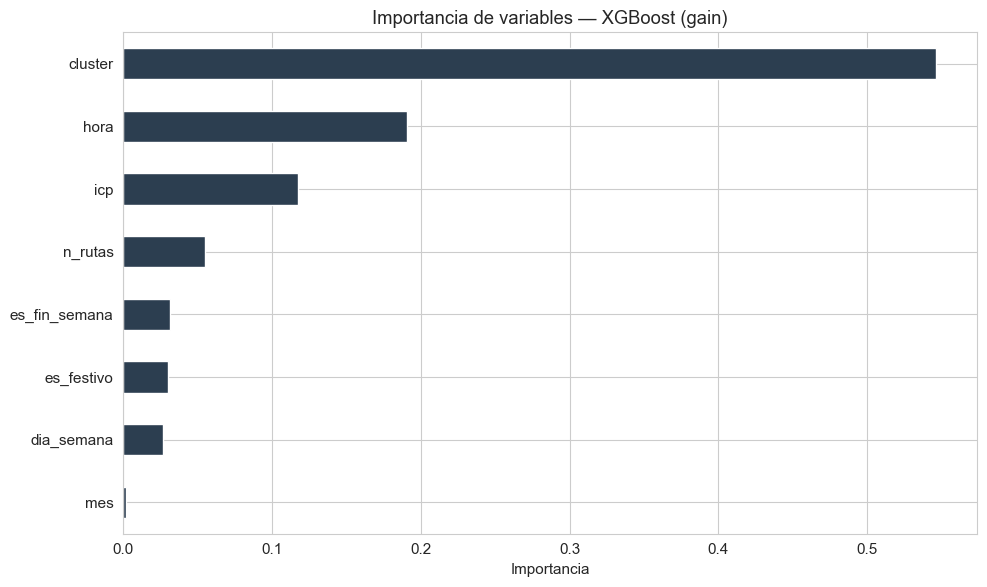

In [9]:
# =============================================
# IMPORTANCIA DE VARIABLES
# =============================================

importance = pd.Series(xgb_full.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
importance.plot(kind='barh', ax=ax, color='#2c3e50')
ax.set_title('Importancia de variables — XGBoost (gain)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig5_importancia_variables.png'), dpi=150, bbox_inches='tight')
plt.show()

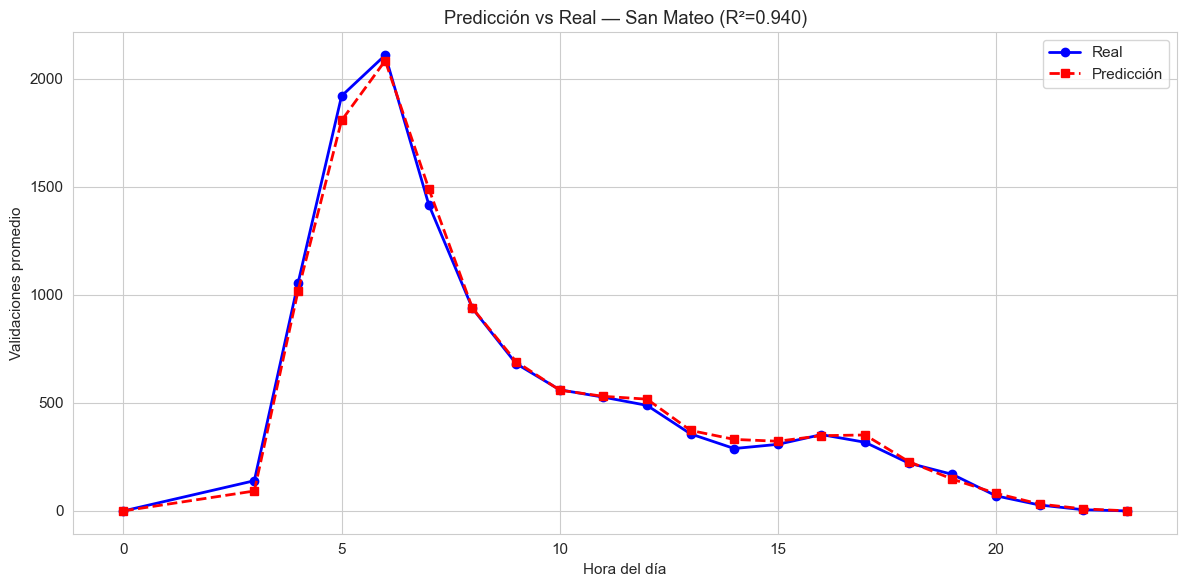

In [10]:
# =============================================
# PREDICCIÓN VS REAL — ESTACIÓN EJEMPLO
# =============================================

test_df = model_df[~train_mask].copy()
test_df['y_pred'] = y_pred_full

station_r2 = {}
for est in test_df['estacion'].unique():
    mask = test_df['estacion'] == est
    if mask.sum() > 100:
        station_r2[est] = r2_score(test_df.loc[mask, 'validaciones'], test_df.loc[mask, 'y_pred'])

best_station = max(station_r2, key=station_r2.get)

est_data = test_df[test_df['estacion'] == best_station]
real_profile = est_data.groupby('hora')['validaciones'].mean()
pred_profile = est_data.groupby('hora')['y_pred'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(real_profile.index, real_profile.values, 'b-o', label='Real', linewidth=2)
ax.plot(pred_profile.index, pred_profile.values, 'r--s', label='Predicción', linewidth=2)
ax.set_title(f'Predicción vs Real — {best_station} (R²={station_r2[best_station]:.3f})')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Validaciones promedio')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig6_prediccion_vs_real.png'), dpi=150, bbox_inches='tight')
plt.show()

### Validación y diagnóstico del modelo

Validación cruzada temporal, análisis de residuos, RMSE desagregado por estación, interpretabilidad (SHAP y permutation importance) e intervalos de confianza por bootstrap.

In [11]:
# =============================================
# VALIDACIÓN CRUZADA TEMPORAL
# =============================================

# Dividir en 5 ventanas temporales
model_df_sorted = model_df.sort_values('fecha')
total = len(model_df_sorted)
n_folds = 5
fold_size = total // n_folds

cv_results = []
print("=== VALIDACIÓN CRUZADA TEMPORAL (5 folds) ===\n")

for fold in range(n_folds):
    # Train: todo lo anterior al fold. Test: el fold.
    test_start = fold * fold_size
    test_end = (fold + 1) * fold_size if fold < n_folds - 1 else total
    
    if fold == 0:
        continue  # Skip: no hay datos de entrenamiento antes del primer fold
    
    train_idx = range(0, test_start)
    test_idx = range(test_start, test_end)
    
    X_tr = model_df_sorted.iloc[list(train_idx)][feature_cols]
    y_tr = model_df_sorted.iloc[list(train_idx)]['validaciones']
    X_te = model_df_sorted.iloc[list(test_idx)][feature_cols]
    y_te = model_df_sorted.iloc[list(test_idx)]['validaciones']
    
    xgb_cv = XGBRegressor(**xgb_params)
    xgb_cv.fit(X_tr, y_tr)
    y_pred_cv = xgb_cv.predict(X_te)
    
    rmse_cv = np.sqrt(mean_squared_error(y_te, y_pred_cv))
    r2_cv = r2_score(y_te, y_pred_cv)
    mae_cv = mean_absolute_error(y_te, y_pred_cv)
    
    fecha_start = model_df_sorted.iloc[test_start]['fecha']
    fecha_end = model_df_sorted.iloc[min(test_end-1, total-1)]['fecha']
    
    cv_results.append({
        'fold': fold, 'train_size': len(train_idx), 'test_size': len(test_idx),
        'fecha_test': f"{fecha_start.strftime('%Y-%m')} a {fecha_end.strftime('%Y-%m')}",
        'rmse': rmse_cv, 'mae': mae_cv, 'r2': r2_cv
    })
    print(f"Fold {fold}: train={len(train_idx):,}, test={len(test_idx):,}, "
          f"periodo={fecha_start.strftime('%Y-%m')}–{fecha_end.strftime('%Y-%m')}, "
          f"RMSE={rmse_cv:.2f}, R²={r2_cv:.4f}")

cv_df = pd.DataFrame(cv_results)
print(f"\nPromedio: RMSE={cv_df['rmse'].mean():.2f} ± {cv_df['rmse'].std():.2f}, "
      f"R²={cv_df['r2'].mean():.4f} ± {cv_df['r2'].std():.4f}")

=== VALIDACIÓN CRUZADA TEMPORAL (5 folds) ===

Fold 1: train=1,591,575, test=1,591,575, periodo=2024-05–2024-10, RMSE=74.68, R²=0.9221
Fold 2: train=3,183,150, test=1,591,575, periodo=2024-10–2025-03, RMSE=75.91, R²=0.9169
Fold 3: train=4,774,725, test=1,591,575, periodo=2025-03–2025-08, RMSE=71.29, R²=0.9275
Fold 4: train=6,366,300, test=1,591,578, periodo=2025-08–2025-12, RMSE=74.76, R²=0.9242

Promedio: RMSE=74.16 ± 1.99, R²=0.9227 ± 0.0044


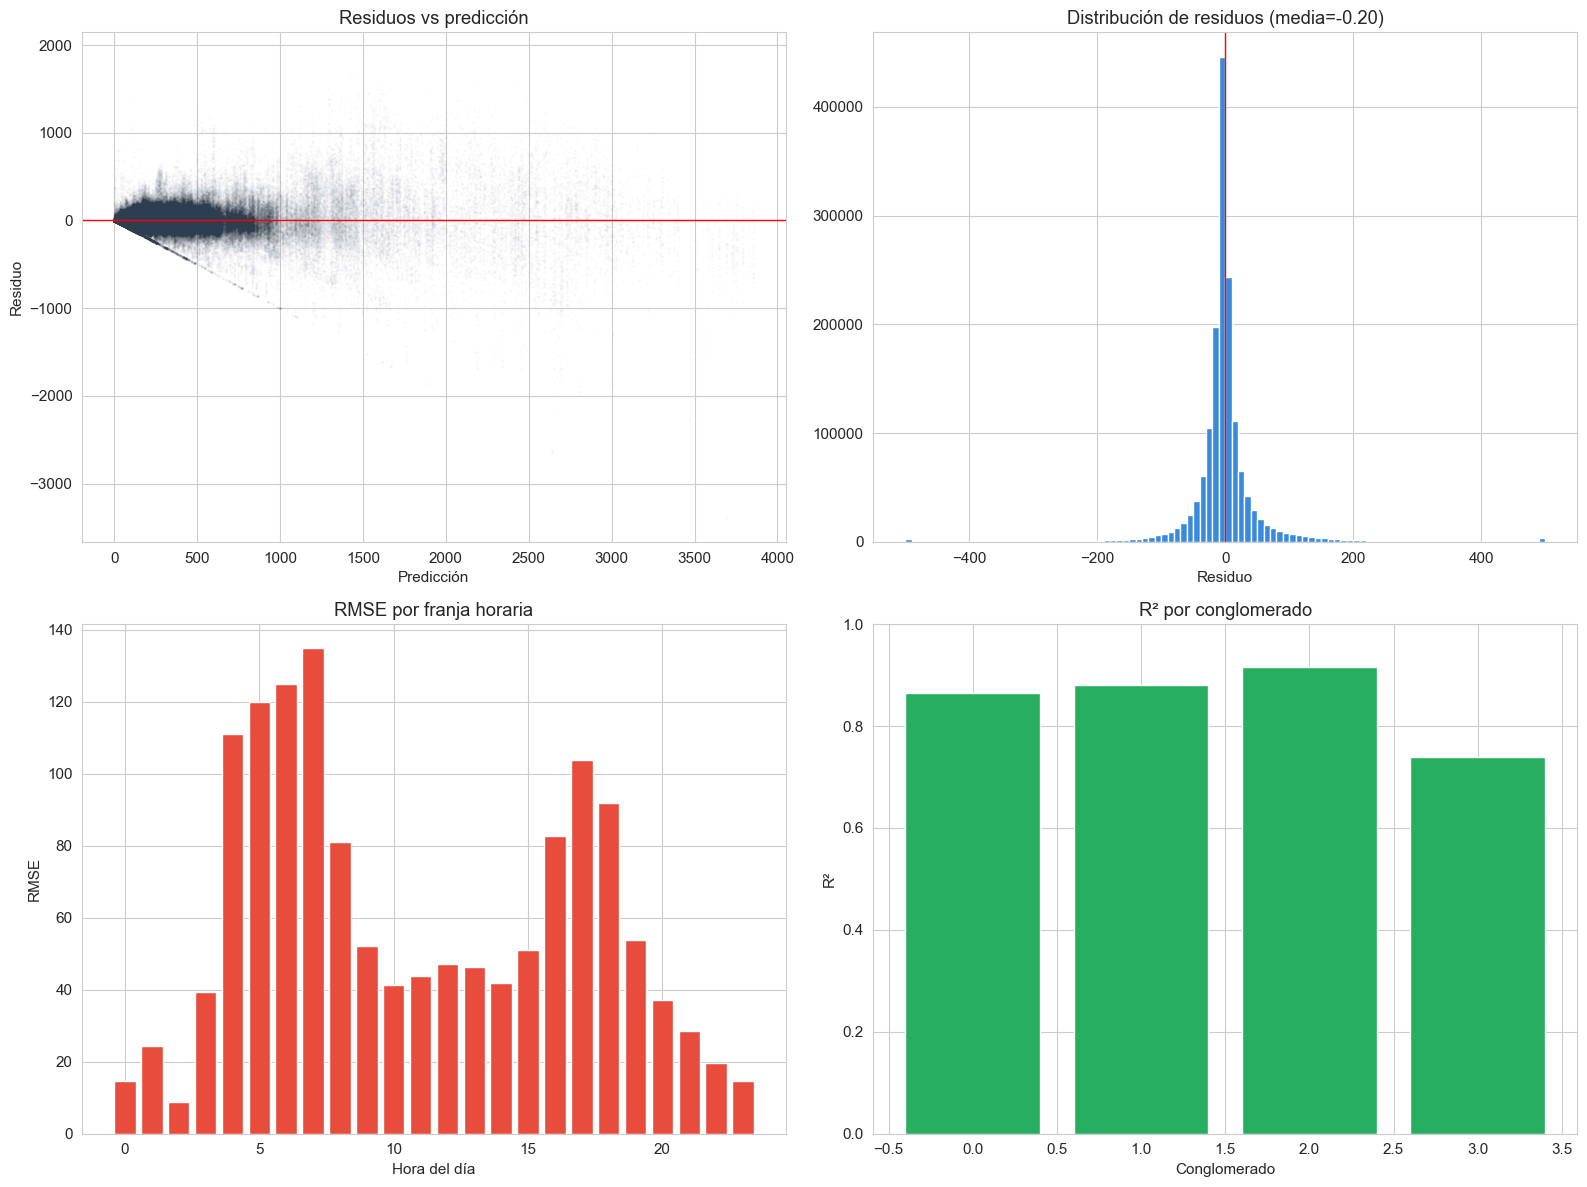

In [12]:
# =============================================
# ANÁLISIS DE RESIDUOS
# =============================================

test_df = model_df[~train_mask].copy()
test_df['y_pred'] = y_pred_full
test_df['residuo'] = test_df['validaciones'] - test_df['y_pred']
test_df['residuo_pct'] = test_df['residuo'] / (test_df['validaciones'] + 1) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Residuos vs predicción
axes[0,0].scatter(test_df['y_pred'], test_df['residuo'], alpha=0.01, s=1, c='#2c3e50')
axes[0,0].axhline(y=0, color='red', linewidth=1)
axes[0,0].set_xlabel('Predicción')
axes[0,0].set_ylabel('Residuo')
axes[0,0].set_title('Residuos vs predicción')

# Panel 2: Distribución de residuos
axes[0,1].hist(test_df['residuo'].clip(-500, 500), bins=100, color='#378ADD', edgecolor='white')
axes[0,1].axvline(x=0, color='red', linewidth=1)
axes[0,1].set_xlabel('Residuo')
axes[0,1].set_title(f'Distribución de residuos (media={test_df["residuo"].mean():.2f})')

# Panel 3: RMSE por hora
rmse_hora = test_df.groupby('hora').apply(
    lambda g: np.sqrt(mean_squared_error(g['validaciones'], g['y_pred']))
).reset_index(name='rmse')
axes[1,0].bar(rmse_hora['hora'], rmse_hora['rmse'], color='#e74c3c')
axes[1,0].set_xlabel('Hora del día')
axes[1,0].set_ylabel('RMSE')
axes[1,0].set_title('RMSE por franja horaria')

# Panel 4: R² por conglomerado
r2_cluster = test_df.groupby('cluster').apply(
    lambda g: r2_score(g['validaciones'], g['y_pred']) if len(g) > 10 else np.nan
).reset_index(name='r2')
r2_cluster['cluster'] = r2_cluster['cluster'].astype(int)
axes[1,1].bar(r2_cluster['cluster'], r2_cluster['r2'], color='#27ae60')
axes[1,1].set_xlabel('Conglomerado')
axes[1,1].set_ylabel('R²')
axes[1,1].set_title('R² por conglomerado')
axes[1,1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_analisis_residuos.png'), dpi=150, bbox_inches='tight')
plt.show()

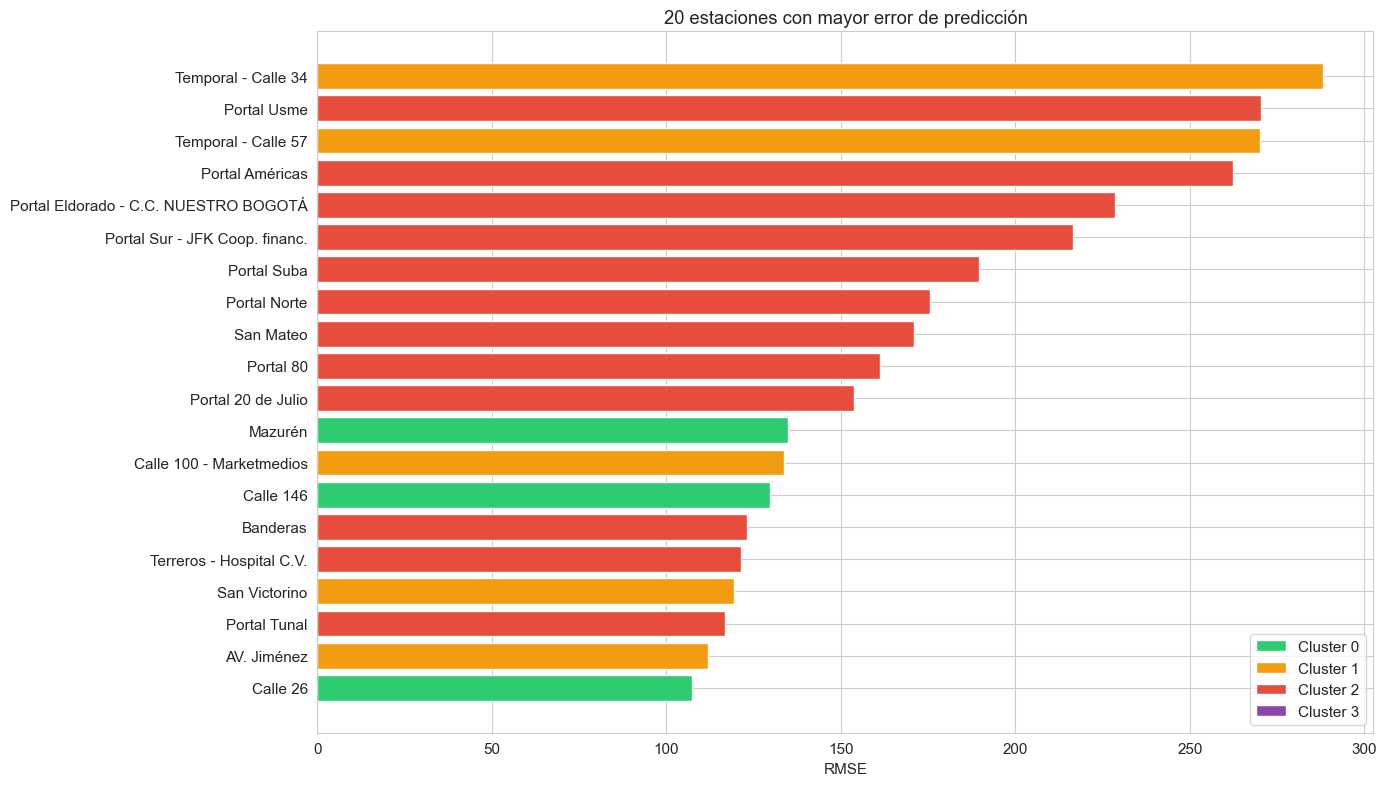

Estaciones con R² < 0.80: 56
Estaciones con R² > 0.95: 0


In [13]:
# =============================================
# RMSE DESAGREGADO POR ESTACIÓN
# =============================================

rmse_est = test_df.groupby('estacion').apply(
    lambda g: pd.Series({
        'rmse': np.sqrt(mean_squared_error(g['validaciones'], g['y_pred'])),
        'r2': r2_score(g['validaciones'], g['y_pred']) if len(g) > 10 else np.nan,
        'n': len(g),
        'cluster': int(g['cluster'].mode().iloc[0]) if len(g) > 0 else -1
    })
).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))
worst_20 = rmse_est.nlargest(20, 'rmse')
colors_map = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 3: '#8e44ad'}
bar_colors = [colors_map.get(int(c), '#999') for c in worst_20['cluster']]
ax.barh(range(len(worst_20)), worst_20['rmse'].values, color=bar_colors)
ax.set_yticks(range(len(worst_20)))
ax.set_yticklabels(worst_20['estacion'].values)
ax.set_xlabel('RMSE')
ax.set_title('20 estaciones con mayor error de predicción')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'Cluster {k}') for k, c in colors_map.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_rmse_por_estacion.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Estaciones con R² < 0.80: {(rmse_est['r2'] < 0.80).sum()}")
print(f"Estaciones con R² > 0.95: {(rmse_est['r2'] > 0.95).sum()}")

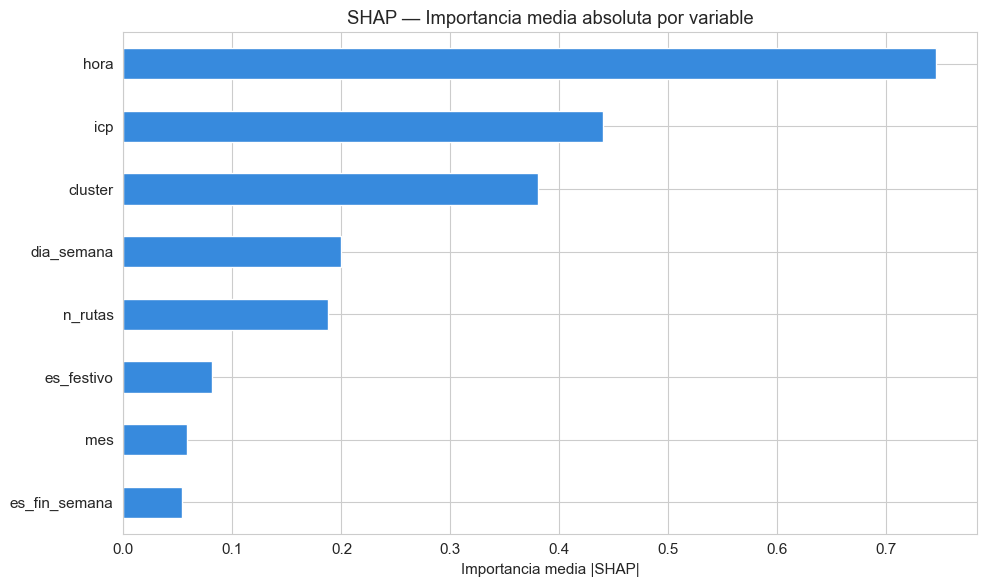

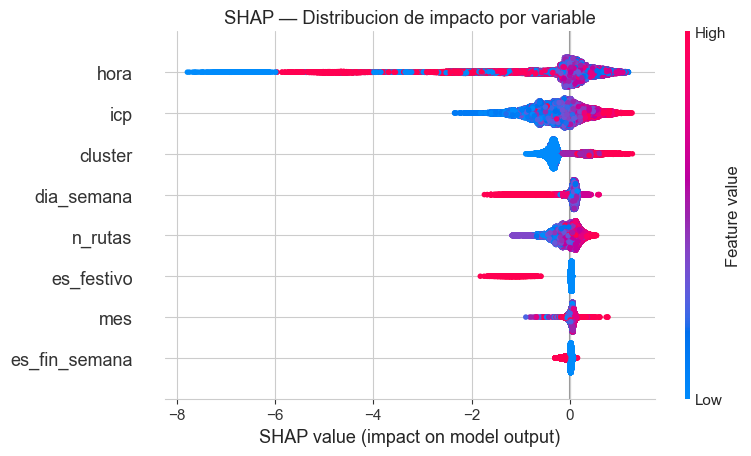

=== COMPARACION: GAIN vs SHAP (normalizado) ===
                gain   shap
hora           0.191  0.347
icp            0.117  0.205
cluster        0.546  0.177
dia_semana     0.026  0.093
n_rutas        0.055  0.087
es_festivo     0.030  0.038
mes            0.002  0.027
es_fin_semana  0.031  0.025


In [14]:
# =============================================
# SHAP VALUES
# =============================================
# Se calculan los valores SHAP con la funcion nativa de XGBoost (pred_contribs),
# que es TreeSHAP, para evitar la incompatibilidad de versiones entre shap y
# xgboost al cargar el modelo. shap se usa solo para la visualizacion.
import xgboost as xgb

# Muestra para velocidad
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(50000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

# SHAP nativo de XGBoost: la ultima columna es el sesgo (base value), se descarta
dmatrix = xgb.DMatrix(X_sample)
shap_contribs = xgb_full.get_booster().predict(dmatrix, pred_contribs=True)
shap_values = shap_contribs[:, :-1]

# Importancia media |SHAP| por variable
shap_mean = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)

# Grafico 1: barra de importancia media |SHAP| (controlado, sin summary_plot)
fig, ax = plt.subplots(figsize=(10, 6))
shap_mean.sort_values().plot(kind='barh', ax=ax, color='#378ADD')
ax.set_xlabel('Importancia media |SHAP|')
ax.set_title('SHAP — Importancia media absoluta por variable')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_shap_importancia.png'), dpi=150, bbox_inches='tight')
plt.show()

# Grafico 2: beeswarm (distribucion de impacto). Figura propia de shap.
try:
    shap.summary_plot(shap_values, X_sample, max_display=10, show=False)
    plt.title('SHAP — Distribucion de impacto por variable')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_FIG, 'fig_shap_beeswarm.png'), dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"(No se pudo generar el beeswarm: {e})")

# Comparacion gain vs SHAP (normalizado)
gain_importance = pd.Series(xgb_full.feature_importances_, index=feature_cols)
comp_imp = pd.DataFrame({
    'gain': gain_importance / gain_importance.sum(),
    'shap': shap_mean / shap_mean.sum()
}).sort_values('shap', ascending=False)

print("=== COMPARACION: GAIN vs SHAP (normalizado) ===")
print(comp_imp.round(3).to_string())

=== PERMUTATION IMPORTANCE ===
     variable  importance_mean  importance_std
         hora     81503.549414     1202.394163
          icp     45124.802930      522.039594
      cluster     42158.677148      402.336608
      n_rutas     12875.874219      178.698226
   dia_semana     11539.229492      374.620428
   es_festivo      5822.830957      369.857686
es_fin_semana      1811.531396       70.927872
          mes       607.886719       51.184445


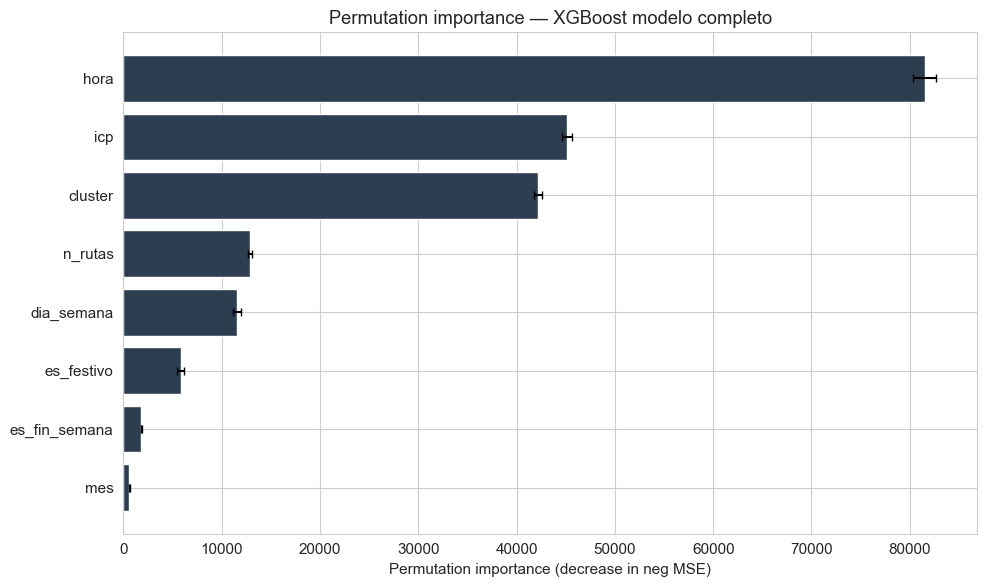

In [15]:
# =============================================
# PERMUTATION IMPORTANCE
# =============================================

from sklearn.inspection import permutation_importance

# Usar muestra para velocidad
sample_size = min(100000, len(X_test))
sample_idx = np.random.RandomState(42).choice(len(X_test), size=sample_size, replace=False)

perm_result = permutation_importance(
    xgb_full, X_test.iloc[sample_idx], y_test.iloc[sample_idx],
    n_repeats=10, random_state=42, n_jobs=-1,
    scoring='neg_mean_squared_error'
)

perm_df = pd.DataFrame({
    'variable': feature_cols,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("=== PERMUTATION IMPORTANCE ===")
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
perm_df_sorted = perm_df.sort_values('importance_mean')
ax.barh(perm_df_sorted['variable'], perm_df_sorted['importance_mean'],
        xerr=perm_df_sorted['importance_std'], color='#2c3e50', capsize=3)
ax.set_xlabel('Permutation importance (decrease in neg MSE)')
ax.set_title('Permutation importance — XGBoost modelo completo')
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_permutation_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

Bootstrap con 1000 iteraciones...

=== INTERVALOS DE CONFIANZA 95% (BOOTSTRAP) ===
  RMSE: 74.49 — 75.51 (punto: 74.97)
  R²:   0.9229 — 0.9250 (punto: 0.9240)

=== DIFERENCIA M2 (ESTRUCTURAL) vs M0 (TEMPORAL) (bootstrap) ===
  ΔRMSE: 177.92 — 180.82 (punto: 179.32)
  ΔR²:   0.7974 — 0.8000 (punto: 0.7986)

  En 100.0% de las muestras bootstrap, M2 (estructural) supera a M0 (temporal).


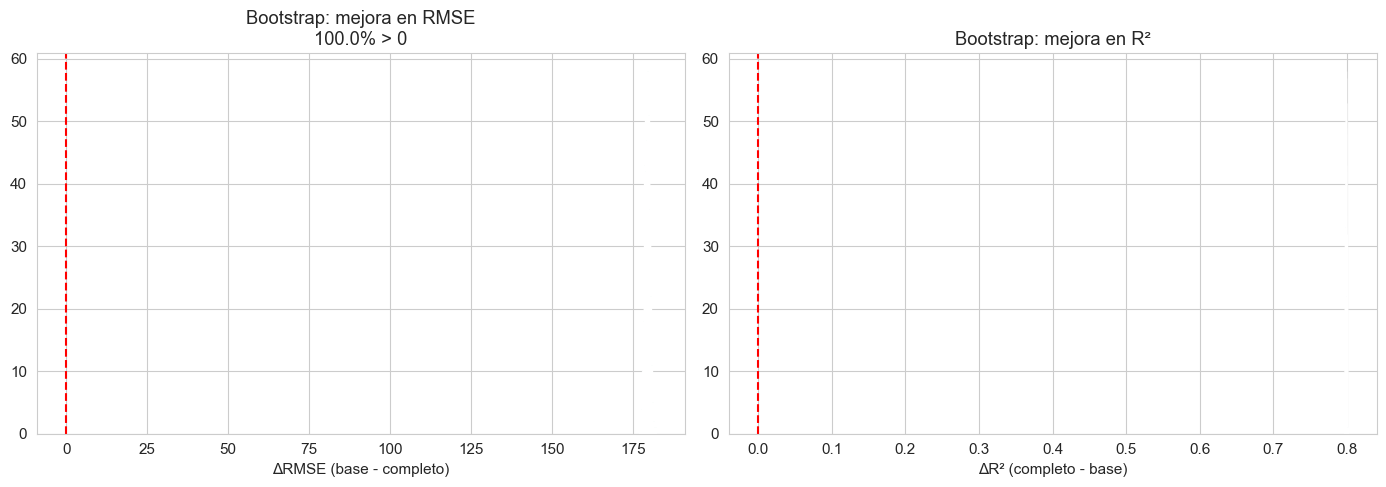

In [16]:
# =============================================
# BOOTSTRAP: INTERVALOS DE CONFIANZA PARA MÉTRICAS
# =============================================

n_bootstrap = 1000
boot_rmse = []
boot_r2 = []

test_indices = np.arange(len(y_test))

print(f"Bootstrap con {n_bootstrap} iteraciones...\n")
np.random.seed(42)
for i in range(n_bootstrap):
    idx = np.random.choice(test_indices, size=len(test_indices), replace=True)
    y_true_boot = y_test.iloc[idx].values
    y_pred_boot = y_pred_full[idx]
    boot_rmse.append(np.sqrt(mean_squared_error(y_true_boot, y_pred_boot)))
    boot_r2.append(r2_score(y_true_boot, y_pred_boot))

boot_rmse = np.array(boot_rmse)
boot_r2 = np.array(boot_r2)

print("=== INTERVALOS DE CONFIANZA 95% (BOOTSTRAP) ===")
print(f"  RMSE: {np.percentile(boot_rmse, 2.5):.2f} — {np.percentile(boot_rmse, 97.5):.2f} (punto: {rmse_full:.2f})")
print(f"  R²:   {np.percentile(boot_r2, 2.5):.4f} — {np.percentile(boot_r2, 97.5):.4f} (punto: {r2_full:.4f})")

# Comparar con modelo base
boot_rmse_base = []
boot_r2_base = []
for i in range(n_bootstrap):
    idx = np.random.choice(test_indices, size=len(test_indices), replace=True)
    y_true_boot = y_test.iloc[idx].values
    y_pred_boot_base = y_pred_base[idx]
    boot_rmse_base.append(np.sqrt(mean_squared_error(y_true_boot, y_pred_boot_base)))
    boot_r2_base.append(r2_score(y_true_boot, y_pred_boot_base))

boot_rmse_base = np.array(boot_rmse_base)
boot_r2_base = np.array(boot_r2_base)

delta_rmse = boot_rmse_base - boot_rmse
delta_r2 = boot_r2 - boot_r2_base

print(f"\n=== DIFERENCIA M2 (ESTRUCTURAL) vs M0 (TEMPORAL) (bootstrap) ===")
print(f"  ΔRMSE: {np.percentile(delta_rmse, 2.5):.2f} — {np.percentile(delta_rmse, 97.5):.2f} (punto: {rmse_base-rmse_full:.2f})")
print(f"  ΔR²:   {np.percentile(delta_r2, 2.5):.4f} — {np.percentile(delta_r2, 97.5):.4f} (punto: {r2_full-r2_base:.4f})")

# ¿La mejora es significativa?
pct_rmse_positive = (delta_rmse > 0).mean() * 100
print(f"\n  En {pct_rmse_positive:.1f}% de las muestras bootstrap, M2 (estructural) supera a M0 (temporal).")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(delta_rmse, bins=50, color='#27ae60', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('ΔRMSE (base - completo)')
axes[0].set_title(f'Bootstrap: mejora en RMSE\n{pct_rmse_positive:.1f}% > 0')

axes[1].hist(delta_r2, bins=50, color='#2980b9', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('ΔR² (completo - base)')
axes[1].set_title(f'Bootstrap: mejora en R²')

plt.tight_layout()
plt.savefig(os.path.join(OUT_FIG, 'fig_bootstrap_metricas.png'), dpi=150, bbox_inches='tight')
plt.show()

### Anticipación de franjas de presión (cierra el OE5)

In [17]:
# =============================================================
# ANTICIPACIÓN DE FRANJAS DE PRESIÓN ALTA
# -------------------------------------------------------------
# IPD esperado = demanda predicha (M2) / ICP de la estacion.
#   - Presion alta:    IPD esperado >= 1.0
#   - Presion critica: IPD esperado >= 1.5
# ATENCION: estos umbrales NO representan saturacion fisica. El ICP es
# estatico e ignora la frecuencia, y su magnitud varia entre estaciones,
# por lo que un mismo IPD equivale a cargas absolutas distintas (ver §3.8).
# Se interpretan como PRESION RELATIVA a la cobertura asignada. Abajo se
# reporta la sensibilidad del desempeno a la eleccion del umbral.
# =============================================================
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

UMBRAL_ALTA = 1.0
UMBRAL_CRIT = 1.5

# test_df (definido en celdas previas) tiene 'validaciones', 'y_pred', 'icp', 'estacion', 'hora'
pres = test_df[test_df['icp'] > 0].copy()
pres['ipd_real']     = pres['validaciones'] / pres['icp']
pres['ipd_esperado'] = pres['y_pred']       / pres['icp']

pres['alta_real'] = (pres['ipd_real']     >= UMBRAL_ALTA).astype(int)
pres['alta_pred'] = (pres['ipd_esperado'] >= UMBRAL_ALTA).astype(int)
pres['crit_real'] = (pres['ipd_real']     >= UMBRAL_CRIT).astype(int)
pres['crit_pred'] = (pres['ipd_esperado'] >= UMBRAL_CRIT).astype(int)


def evaluar(y_true, y_pred, etiqueta):
    cm = confusion_matrix(y_true, y_pred)
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {etiqueta} ---")
    print(f"  Franjas observadas:   {int(y_true.sum()):,}")
    print(f"  Franjas anticipadas:  {int(y_pred.sum()):,}")
    print(f"  Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")
    print(f"  Matriz de confusion [[TN FP] [FN TP]]:\n{cm}\n")
    return p, r, f1


print("=" * 60)
print("ANTICIPACION DE FRANJAS DE PRESION — CONJUNTO DE PRUEBA")
print(f"Registros evaluados: {len(pres):,}")
print("=" * 60 + "\n")
evaluar(pres['alta_real'], pres['alta_pred'], f"Presion alta (IPD esperado >= {UMBRAL_ALTA})")
evaluar(pres['crit_real'], pres['crit_pred'], f"Presion critica (IPD esperado >= {UMBRAL_CRIT})")

# --- Sensibilidad a la eleccion del umbral (robustez, §3.8) ---
print("Sensibilidad del desempeno al umbral de presion:")
print(f"  {'Umbral':>7}{'Precision':>11}{'Recall':>9}{'F1':>7}")
for u in [0.8, 1.0, 1.2]:
    yt = (pres['ipd_real'] >= u).astype(int)
    yp = (pres['ipd_esperado'] >= u).astype(int)
    print(f"  {u:>7.1f}{precision_score(yt, yp, zero_division=0):>11.3f}"
          f"{recall_score(yt, yp, zero_division=0):>9.3f}{f1_score(yt, yp, zero_division=0):>7.3f}")

# Estaciones donde mas se anticipa presion alta
resumen_estacion = (
    pres.groupby('estacion')
        .agg(intervalos=('alta_pred', 'size'),
             franjas_anticipadas=('alta_pred', 'sum'),
             franjas_observadas=('alta_real', 'sum'),
             ipd_esperado_max=('ipd_esperado', 'max'))
        .assign(tasa_anticipada=lambda d: d['franjas_anticipadas'] / d['intervalos'])
        .sort_values('franjas_anticipadas', ascending=False)
        .head(15)
)
print("\nTop 15 estaciones por franjas de presion alta anticipadas:")
print(resumen_estacion.round(3).to_string())

# Franjas horarias con mayor proporcion de presion alta anticipada
resumen_hora = pres.groupby('hora')['alta_pred'].mean().sort_values(ascending=False).head(8)
print("\nFranjas horarias con mayor proporcion de presion alta anticipada (%):")
print((resumen_hora * 100).round(1).to_string())

ANTICIPACION DE FRANJAS DE PRESION — CONJUNTO DE PRUEBA
Registros evaluados: 1,585,144

--- Presion alta (IPD esperado >= 1.0) ---
  Franjas observadas:   14,675
  Franjas anticipadas:  10,768
  Precision: 0.768 | Recall: 0.564 | F1: 0.650
  Matriz de confusion [[TN FP] [FN TP]]:
[[1567974    2495]
 [   6402    8273]]

--- Presion critica (IPD esperado >= 1.5) ---
  Franjas observadas:   2,032
  Franjas anticipadas:  976
  Precision: 0.566 | Recall: 0.272 | F1: 0.367
  Matriz de confusion [[TN FP] [FN TP]]:
[[1582688     424]
 [   1480     552]]

Sensibilidad del desempeno al umbral de presion:
   Umbral  Precision   Recall     F1
      0.8      0.788    0.634  0.703
      1.0      0.768    0.564  0.650
      1.2      0.657    0.464  0.544

Top 15 estaciones por franjas de presion alta anticipadas:
                                       intervalos  franjas_anticipadas  franjas_observadas  ipd_esperado_max  tasa_anticipada
estacion                                                        

## 12. Exportación de resultados

In [18]:
# =============================================
# GUARDAR RESULTADOS
# =============================================

icp.to_csv(os.path.join(OUT_TAB, 'icp_estaciones.csv'), index=False)
print(f"Guardado: icp_estaciones.csv ({len(icp)} estaciones)")

ipd_export = ipd_df[['estacion', 'fecha', 'intervalo', 'hora', 'dia_semana', 'mes',
                     'validaciones', 'icp', 'n_rutas', 'ipd', 'cluster']].copy()
ipd_export.to_csv(os.path.join(OUT_TAB, 'ipd_completo.csv'), index=False)
print(f"Guardado: ipd_completo.csv ({len(ipd_export):,} filas)")

cluster_df.to_csv(os.path.join(OUT_TAB, 'conglomerados_estaciones.csv'), index=False)
print(f"Guardado: conglomerados_estaciones.csv ({len(cluster_df)} estaciones)")

metricas = pd.DataFrame({
    'Modelo': ['M0 (temporal)', 'M1 (efectos fijos de estacion)',
               'M2 (estructural)', 'Random Forest (M2)'],
    'RMSE': [rmse_base, rmse_m1, rmse_full, rmse_rf],
    'MAE':  [mae_base,  mae_m1,  mae_full,  mae_rf],
    'R2':   [r2_base,   r2_m1,   r2_full,   r2_rf]
})
metricas.to_csv(os.path.join(OUT_TAB, 'metricas_modelo.csv'), index=False)
print("Guardado: metricas_modelo.csv")
print(metricas.round(4).to_string(index=False))
print("\nTodos los resultados exportados.")

Guardado: icp_estaciones.csv (216 estaciones)
Guardado: ipd_completo.csv (7,957,878 filas)
Guardado: conglomerados_estaciones.csv (144 estaciones)
Guardado: metricas_modelo.csv
                        Modelo     RMSE      MAE     R2
                 M0 (temporal) 254.2908 120.8950 0.1253
M1 (efectos fijos de estacion)  82.9686  37.1721 0.9069
              M2 (estructural)  74.9742  31.8417 0.9240
            Random Forest (M2) 115.5221  57.4381 0.8195

Todos los resultados exportados.
